In [96]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import glob
from sklearn import cluster, metrics, model_selection, ensemble
from scipy import stats as st

import seaborn as sns

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score, accuracy_score


from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif

In [4]:
data_directory = 'G:/My Drive/kaggle_data/FoG_prediction/'

In [5]:
# Read the data and append the Id
def read_data(path):
    df = pd.read_csv(path)
    df['Id'] = path.split("\\")[-1].split(".")[0]
    
    return df


# Read and concatenate all files of the train data from specified dataset
def create_full_data(dataset_name):
    paths = glob.glob(data_directory + f'train/{dataset_name}/*')
    final_df = pd.concat([read_data(p) for p in paths])
    final_df['dataset'] = dataset_name
    
    return final_df

#### Metadatas

In [13]:
tdcsfog_metadata_df = pd.read_csv(data_directory+"tdcsfog_metadata.csv")
defog_metadata_df = pd.read_csv(data_directory+"defog_metadata.csv")
subjects_df = pd.read_csv(data_directory+"subjects.csv")
events_df = pd.read_csv(data_directory+"events.csv")
tasks_df = pd.read_csv(data_directory+"tasks.csv")
daily_metadata_df = pd.read_csv(data_directory+"daily_metadata.csv")


In [9]:
tdcsfog_metadata_df.head()

,Id,Subject,Visit,Test,Medication
0,003f117e14,4dc2f8,3,2,on
1,009ee11563,f62eec,4,2,on
2,011322847a,231c3b,2,2,on
3,01d0fe7266,231c3b,2,1,off
4,024418ba39,fa8764,19,3,on


In [10]:
defog_metadata_df.head()

,Id,Subject,Visit,Medication
0,02ab235146,e1f62e,2,on
1,02ea782681,ae2d35,2,on
2,06414383cf,8c1f5e,2,off
3,092b4c1819,2874c5,1,off
4,0a900ed8a2,0e3d49,2,on


In [11]:
subjects_df.head()

,Subject,Visit,Age,Sex,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ
0,00f674,2.0,63,M,27.0,43.0,49.0,24
1,00f674,1.0,63,M,27.0,31.0,30.0,26
2,02bc69,NaN,69,M,4.0,21.0,NaN,22
3,040587,2.0,75,M,26.0,52.0,69.0,21
4,040587,1.0,75,M,26.0,47.0,75.0,24


In [14]:
events_df.head()

,Id,Init,Completion,Type,Kinetic
0,003f117e14,8.61312,14.7731,Turn,1.0
1,009ee11563,11.38470,41.1847,Turn,1.0
2,009ee11563,54.66470,58.7847,Turn,1.0
3,011322847a,28.09660,30.2966,Turn,1.0
4,01d0fe7266,30.31840,31.8784,Turn,1.0


In [16]:
tasks_df["Duration"] = tasks_df.End - tasks_df.Begin
tasks_df.head()

,Id,Begin,End,Task,Duration
0,02ab235146,10.00,190.48,Rest1,180.48
1,02ab235146,211.24,271.56,Rest2,60.32
2,02ab235146,505.88,522.40,4MW,16.52
3,02ab235146,577.96,594.64,4MW-C,16.68
4,02ab235146,701.32,715.28,MB1,13.96


In [12]:
daily_metadata_df.head()

,Id,Subject,Visit,Beginning of recording [00:00-23:59]
0,00c4c9313d,fba3a3,1,10:19
1,07a96f89ec,7da72f,1,07:30
2,0d1bc672a8,056372,2,08:30
3,0e333c9833,b4bd22,1,11:30
4,164adaed7b,9f72eb,1,13:00


In [34]:
# Create a dataframe with all defog data
defog_data = create_full_data('defog')
print(defog_data.shape)
defog_data.head()

(13525702, 11)


,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task,Id,dataset
0,0,-1.0,0.044129,-0.25,0,0,0,False,False,02ea782681,defog
1,1,-1.0,0.034431,-0.25,0,0,0,False,False,02ea782681,defog
2,2,-1.0,0.031250,-0.25,0,0,0,False,False,02ea782681,defog
3,3,-1.0,0.031250,-0.25,0,0,0,False,False,02ea782681,defog
4,4,-1.0,0.031250,-0.25,0,0,0,False,False,02ea782681,defog


In [58]:
valid_defog_data = defog_data[(defog_data['Task'] == 1) & (defog_data['Valid'] == 1)].drop(['Task','Valid'], axis=1).reset_index(drop=True)
print(valid_defog_data.shape)
valid_defog_data.head()

(4090530, 9)


,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,dataset
0,1000,-0.970018,0.061626,-0.265625,0,0,0,02ea782681,defog
1,1001,-0.984375,0.044497,-0.265625,0,0,0,02ea782681,defog
2,1002,-0.984375,0.029016,-0.265625,0,0,0,02ea782681,defog
3,1003,-0.984375,0.015625,-0.265625,0,0,0,02ea782681,defog
4,1004,-0.984670,0.015330,-0.265625,0,0,0,02ea782681,defog


In [59]:
valid_defog_data.describe()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
count,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06
mean,9.112536e+04,-9.349461e-01,-1.229101e-03,-2.257802e-01,1.222335e-04,1.434604e-01,2.408441e-02
std,7.025916e+04,1.072241e-01,1.401177e-01,2.444683e-01,1.105525e-02,3.505418e-01,1.533113e-01
min,1.000000e+03,-6.024701e+00,-2.115008e+00,-5.118650e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.552900e+04,-9.852707e-01,-8.466136e-02,-3.634808e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.682200e+04,-9.392389e-01,0.000000e+00,-2.500000e-01,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.295620e+05,-8.869629e-01,9.248055e-02,-1.132356e-01,0.000000e+00,0.000000e+00,0.000000e+00
max,4.143870e+05,4.458365e+00,4.524038e+00,4.388132e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [18]:
# Create a dataframe with all tdcsfog data
tdcsfog_data = create_full_data('tdcsfog')
tdcsfog_data.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,dataset
0,0,-9.533939,0.566322,-1.413525,0,0,0,003f117e14,tdcsfog
1,1,-9.536140,0.564137,-1.440621,0,0,0,003f117e14,tdcsfog
2,2,-9.529345,0.561765,-1.429332,0,0,0,003f117e14,tdcsfog
3,3,-9.531239,0.564227,-1.415490,0,0,0,003f117e14,tdcsfog
4,4,-9.540825,0.561854,-1.429471,0,0,0,003f117e14,tdcsfog


In [38]:
tdcsfog_data.describe()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
count,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06
mean,9.289467e+03,-9.306317e+00,-2.012513e-01,1.808524e+00,4.315506e-02,2.376979e-01,2.942767e-02
std,1.399893e+04,1.080174e+00,1.269525e+00,2.285849e+00,2.032061e-01,4.256731e-01,1.690020e-01
min,0.000000e+00,-3.552112e+01,-2.616440e+01,-4.782964e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.119000e+03,-9.762402e+00,-9.295446e-01,5.672254e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.310000e+03,-9.363524e+00,-1.722245e-01,1.987101e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.433000e+03,-8.776814e+00,5.752114e-01,3.449026e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,9.707600e+04,2.090695e+01,2.748472e+01,3.033769e+01,1.000000e+00,1.000000e+00,1.000000e+00


### Look at AccV, AccML and AccP distributions
### Data is in units of m/s^2 for tdcsfog/ and g for defog/ and notype/ 
### 1 m/s^2 to g-unit = 0.10197 g-unit

#### AccV: Let's look at two distributions (tdcsfog_AccV and defog_AccV) and find whether their probabilities are the same or not.




In [60]:
Const = 0.10197
tdcsfog_AccV = tdcsfog_data['AccV'] * Const
defog_AccV = valid_defog_data['AccV']
print(tdcsfog_AccV.mean())
print(defog_AccV.mean())

-0.9489651004960586
-0.9349461219547196


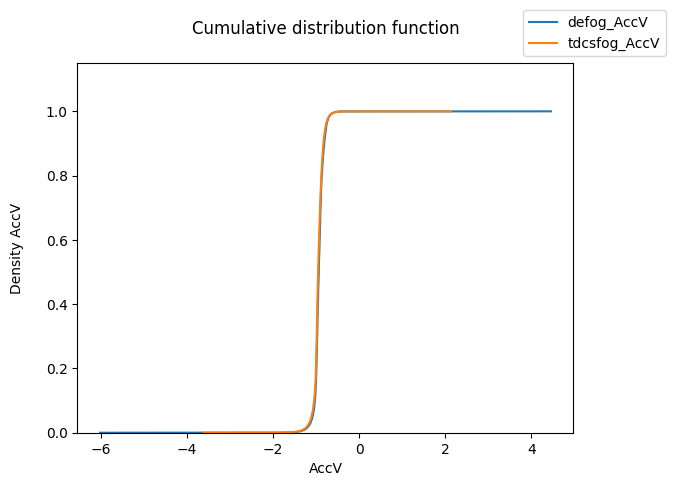

In [62]:
sns.histplot(data=defog_AccV,  bins=len(defog_AccV), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='defog_AccV')

sns.histplot(data=tdcsfog_AccV, bins=len(tdcsfog_AccV), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='tdcsfog_AccV')

plt.xlabel('AccV')
plt.ylabel('Density AccV'+ '\n')
plt.ylim([0.0, 1.15])
plt.legend(bbox_to_anchor=(1.2, 1), loc='lower right')
plt.title('Cumulative distribution function' + '\n')
plt.show()

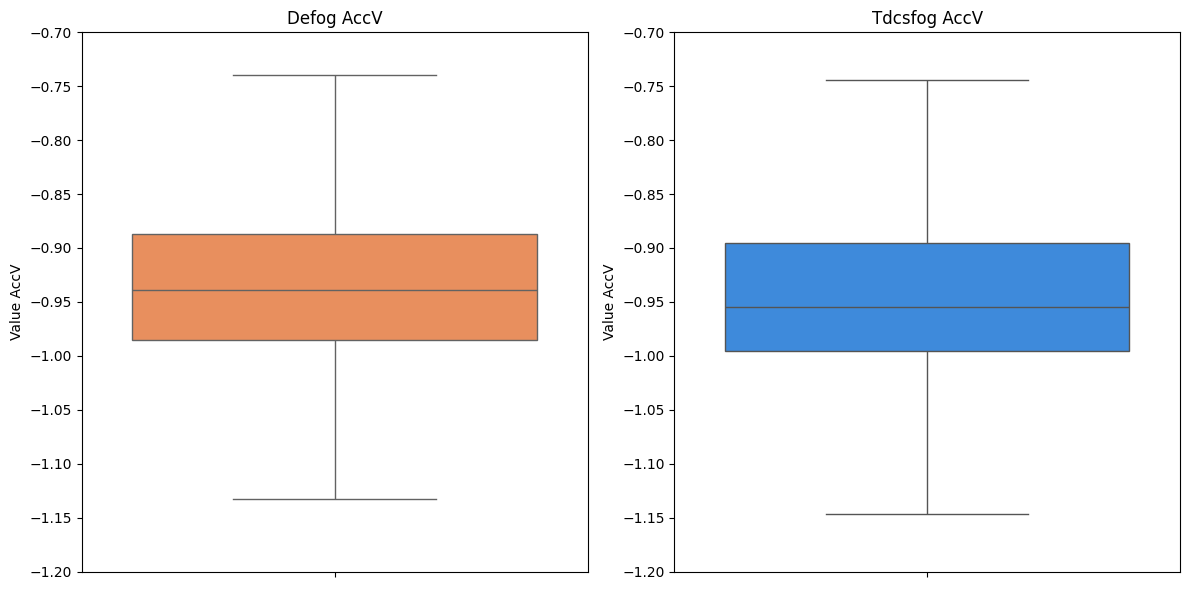

In [93]:
# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
rainbow_palette = sns.color_palette("rainbow", n_colors=10)  

# Boxplot for defog_AccV
sns.boxplot(
    ax=axes[0], 
    data=defog_AccV, 
    color=rainbow_palette[8],
    showfliers=False
)
axes[0].set_title('Defog AccV')
axes[0].set_ylabel('Value AccV')

# Boxplot for tdcsfog_AccV
sns.boxplot(
    ax=axes[1], 
    data=tdcsfog_AccV, 
    color=rainbow_palette[1],
    showfliers=False
)
axes[1].set_title('Tdcsfog AccV')
axes[1].set_ylabel('Value AccV')


# Set y-ticks to be the same across both subplots
y_ticks = sorted(set(axes[0].get_yticks()).union(set(axes[1].get_yticks())))
axes[0].set_yticks(y_ticks)
axes[1].set_yticks(y_ticks)

# Show the plots
plt.tight_layout()
plt.show()

#### AccML: Let's look at two distributions (tdcsfog_AccML and defog_AccML) and find whether their probabilities are the same or not.


In [78]:
tdcsfog_AccML = tdcsfog_data['AccML'] * Const
defog_AccML = valid_defog_data['AccML']
print('mean tdcsfog AccML =', tdcsfog_AccML.mean())
print('mean defog AccML =', defog_AccML.mean())

mean tdcsfog AccML = -0.020521594881632733
mean defog AccML = -0.0012291013734006978


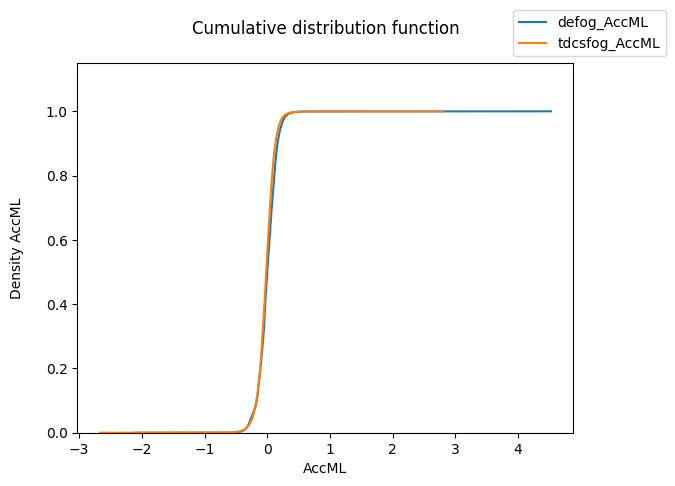

In [82]:
sns.histplot(data=defog_AccML,  bins=len(defog_AccML), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='defog_AccML')

sns.histplot(data=tdcsfog_AccML, bins=len(tdcsfog_AccML), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='tdcsfog_AccML')

plt.xlabel('AccML')
plt.ylabel('Density AccML'+ '\n')
plt.ylim([0.0, 1.15])
plt.legend(bbox_to_anchor=(1.2, 1), loc='lower right')
plt.title('Cumulative distribution function' + '\n')
plt.show()

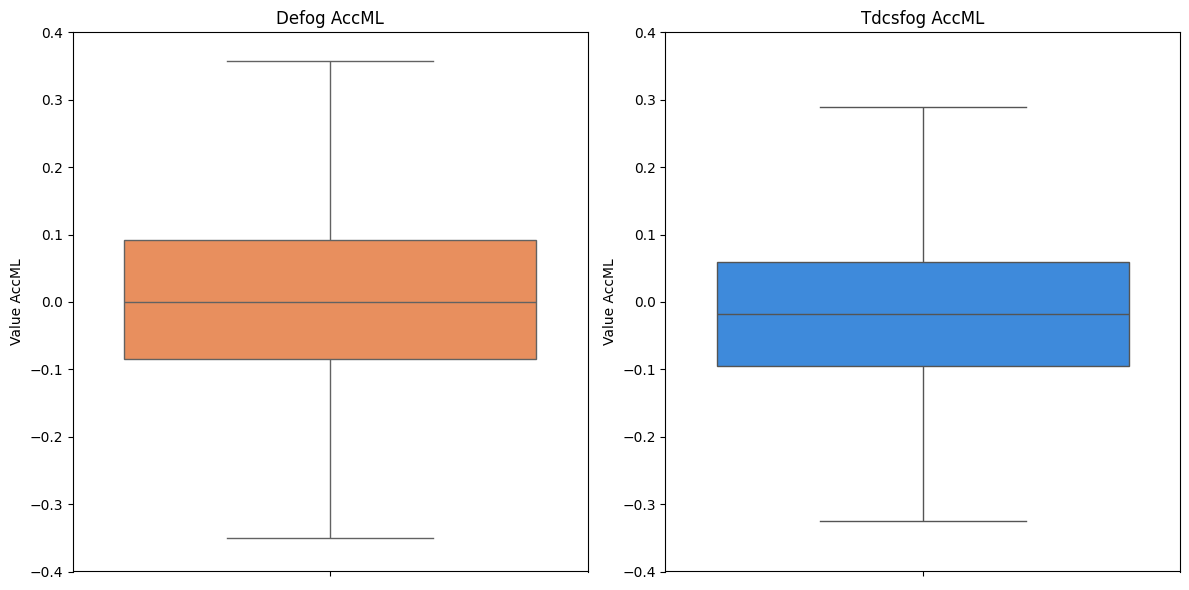

In [91]:
# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Boxplot for defog_AccML
sns.boxplot(
    ax=axes[0], 
    data=defog_AccML, 
    color=rainbow_palette[8],
    showfliers=False
)
axes[0].set_title('Defog AccML')
axes[0].set_ylabel('Value AccML')

# Boxplot for tdcsfog_AccML
sns.boxplot(
    ax=axes[1], 
    data=tdcsfog_AccML, 
    color=rainbow_palette[1],
    showfliers=False
)
axes[1].set_title('Tdcsfog AccML')
axes[1].set_ylabel('Value AccML')


# Set y-ticks to be the same across both subplots
y_ticks = sorted(set(axes[0].get_yticks()).union(set(axes[1].get_yticks())))
axes[0].set_yticks(y_ticks)
axes[1].set_yticks(y_ticks)

# Show the plots
plt.tight_layout()
plt.show()

#### AccAP: Let's look at two distributions (tdcsfog_AccAP and defog_AccAP ) and find whether their probabilities are the same or not.


In [83]:
tdcsfog_AccAP = tdcsfog_data['AccAP'] * Const
defog_AccAP = valid_defog_data['AccAP']
print('mean tdcsfog AccAP =', tdcsfog_AccAP.mean())
print('mean defog AccAP =', defog_AccAP.mean())

mean tdcsfog AccAP = 0.18441523061044188
mean defog AccAP = -0.2257801602045012


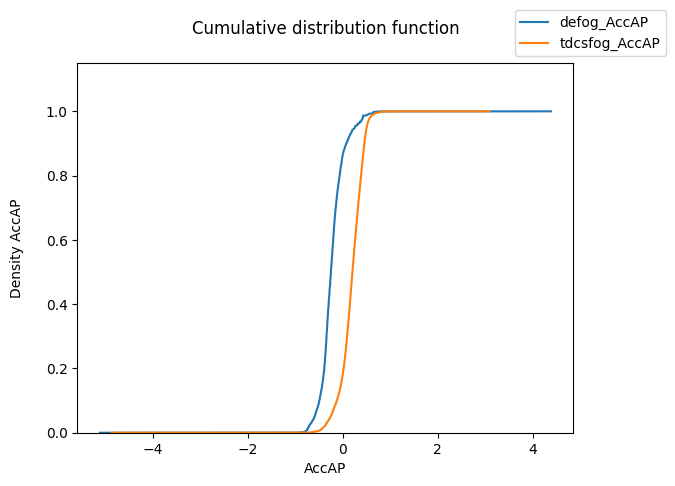

In [84]:
sns.histplot(data=defog_AccAP,  bins=len(defog_AccAP), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='defog_AccAP');

sns.histplot(data=tdcsfog_AccAP, bins=len(tdcsfog_AccAP), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='tdcsfog_AccAP');

plt.xlabel('AccAP')
plt.ylabel('Density AccAP'+ '\n')
plt.ylim([0.0, 1.15])
plt.legend(bbox_to_anchor=(1.2, 1), loc='lower right')
plt.title('Cumulative distribution function' + '\n')
plt.show();

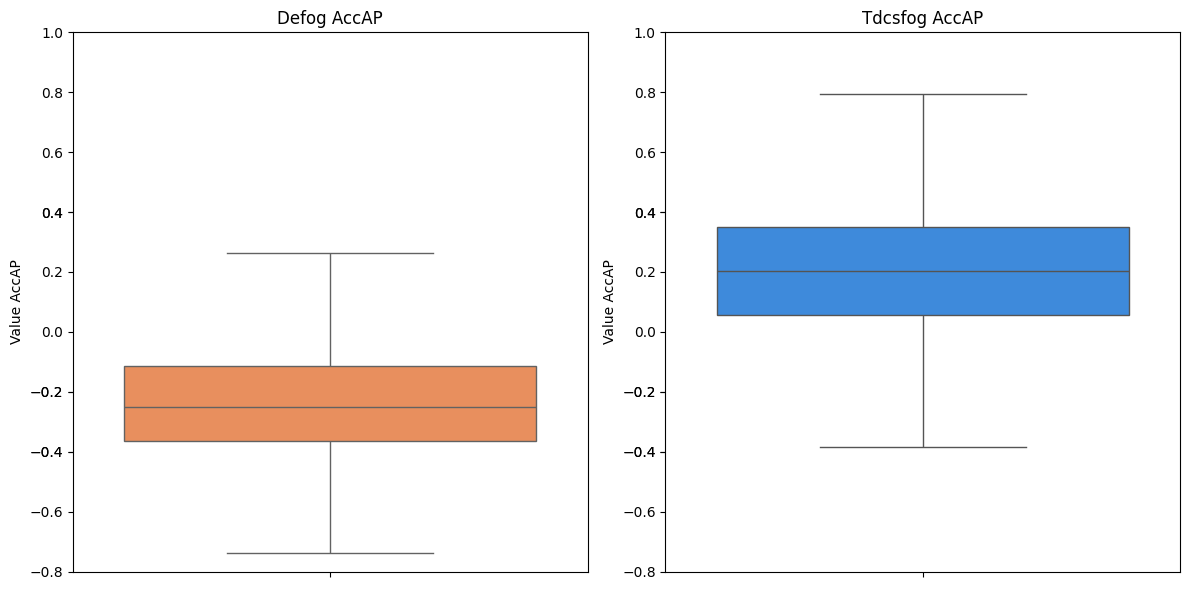

In [90]:
# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Boxplot for defog_AccAP
sns.boxplot(
    ax=axes[0], 
    data=defog_AccAP, 
    color=rainbow_palette[8],
    showfliers=False
)
axes[0].set_title('Defog AccAP')
axes[0].set_ylabel('Value AccAP')

# Boxplot for tdcsfog_AccAP
sns.boxplot(
    ax=axes[1], 
    data=tdcsfog_AccAP, 
    color=rainbow_palette[1],
    showfliers=False
)
axes[1].set_title('Tdcsfog AccAP')
axes[1].set_ylabel('Value AccAP')

# Set y-ticks to be the same across both subplots
y_ticks = sorted(set(axes[0].get_yticks()).union(set(axes[1].get_yticks())))
axes[0].set_yticks(y_ticks)
axes[1].set_yticks(y_ticks)

# Show the plots
plt.tight_layout()
plt.show()

### Statistical function

In [97]:
def t_test_verbose(a, sample2=None, mean=None, fn=None):
    abar = a.mean()
    avar = a.var(ddof=1)  
    na = a.size
    adof = na - 1
    conf_int = st.t.interval(0.95, len(a)-1, 
                                loc=np.mean(a), scale=st.sem(a))

    if type(a) == type(sample2):
        bbar = sample2.mean()
        bvar = sample2.var(ddof=1)
        nb = sample2.size
        bdof = nb - 1

        dof = (avar/na + bvar/nb)**2 /   \
              (avar**2/(na**2*adof) + bvar**2/(nb**2*bdof))
        return {'p-value'           : 
                   fn(a, sample2, equal_var=False).pvalue,  
                'degrees of freedom       ' : dof,  #t_test(a, b),   
                'confidential interval 95%' : conf_int,         
                'n1             ' : a.count(),
                'n2             ' : sample2.count(),
                'average tdcsfog' : a.mean(),
                'average defog'   : sample2.mean(),
                'variance tdcsfog ' : a.var(),
                'variance defog ' : sample2.var(),
                't-statistic' : fn( a, sample2, equal_var=False ).statistic} 

#### Statistical significance AccV
#### H0: Distribution of defog AccP is NOT the same as tdcsfog

#### H1: Distribution of defog AccP is the same as tdcsfog

In [98]:
results_AccV = st.ttest_ind(tdcsfog_AccV, defog_AccV)
alpha_V = 0.05
print('p-value:', results_AccV.pvalue)
if results_AccV.pvalue < alpha_V:
    print('Reject H0: probably the same distributions')
else:
    print('Cannot reject H0: probably different distribution') 

p-value: 0.0
Reject H0: probably the same distributions


In [99]:
pd.Series(t_test_verbose(tdcsfog_AccV, sample2=defog_AccV, fn=st.ttest_ind))


p-value                                                             0.0
degrees of freedom                                       8729837.021288
confidential interval 95%    (-0.9490463330036306, -0.9488838679884867)
n1                                                              7062672
n2                                                              4090530
average tdcsfog                                               -0.948965
average defog                                                 -0.934946
variance tdcsfog                                               0.012132
variance defog                                                 0.011497
t-statistic                                                 -208.326185
dtype: object

#### Statistical significance AccML
#### H0: Distribution of defog AccML is NOT the same as tdcsfog

#### H1: Distribution of defog AccML is the same as tdcsfog

In [100]:
results_AccML = st.ttest_ind(tdcsfog_AccML, defog_AccML)
alpha_ML = 0.05
print('p-value:', results_AccML.pvalue)
if results_AccML.pvalue < alpha_ML:
    print('Reject H0: probably the same distributions')
else:
    print('Cannot reject H0: probably different distribution') 

p-value: 0.0
Reject H0: probably the same distributions


In [101]:
pd.Series(t_test_verbose(tdcsfog_AccML, sample2=defog_AccML, fn=st.ttest_ind))


p-value                                                                0.0
degrees of freedom                                          8002029.155936
confidential interval 95%    (-0.02061706715111597, -0.020426122612149496)
n1                                                                 7062672
n2                                                                 4090530
average tdcsfog                                                  -0.020522
average defog                                                    -0.001229
variance tdcsfog                                                  0.016758
variance defog                                                    0.019633
t-statistic                                                    -227.801298
dtype: object

#### Statistical significance AccAP
#### H0: Distribution of defog AccAP is NOT the same as tdcsfog

#### H1: Distribution of defog AccAP is the same as tdcsfog

In [102]:
results_AP = st.ttest_ind(tdcsfog_AccAP, defog_AccAP)
alpha_AP = 0.05
print('p-value:', results_AP.pvalue)
if results_AP.pvalue < alpha_AP:
    print('Reject H0: probably the same distributions')
else:
    print('Cannot reject H0: probably different distribution')  

p-value: 0.0
Reject H0: probably the same distributions


In [103]:
pd.Series(t_test_verbose(tdcsfog_AccAP, sample2=defog_AccAP, fn=st.ttest_ind))


p-value                                                            0.0
degrees of freedom                                       8213201.81071
confidential interval 95%    (0.1842433275707617, 0.18458713365012205)
n1                                                             7062672
n2                                                             4090530
average tdcsfog                                               0.184415
average defog                                                 -0.22578
variance tdcsfog                                               0.05433
variance defog                                                0.059765
t-statistic                                                2746.682215
dtype: object

### Conclusion: As we can see distributions of AccP, AccV and AccML probably are the same

### tasks clustering
###  This transformation allows to see the total duration for each task per ID, resulting in a DataFrame where each row represents an ID and each column represents a task.

In [29]:
tasks_df[tasks_df.Id == '02ab235146'][tasks_df[tasks_df.Id == '02ab235146'].Task.duplicated(keep=False)]


,Id,Begin,End,Task,Duration
7,02ab235146,775.640,787.560,MB3-R,11.920
8,02ab235146,803.680,813.560,MB3-R,9.880
9,02ab235146,829.440,831.296,MB3-L,1.856
10,02ab235146,831.757,835.960,MB3-L,4.203
22,02ab235146,1771.880,1790.680,TUG-ST,18.800
23,02ab235146,1798.800,1816.240,TUG-ST,17.440
24,02ab235146,1864.040,1883.840,TUG-DT,19.800
25,02ab235146,1915.800,1943.920,TUG-DT,28.120
26,02ab235146,2022.120,2043.440,TUG-C,21.320
27,02ab235146,2068.440,2085.560,TUG-C,17.120


In [ ]:
tasks_pivot_table = pd.pivot_table(tasks_df, values=['Duration'], index=['Id'], columns=['Task'], aggfunc='sum', fill_value=0)
tasks.columns = [c[-1] for c in tasks.columns]
tasks = tasks.reset_index()
tasks['t_kmeans'] = cluster.KMeans(n_clusters=10, random_state=3).fit_predict(tasks[tasks.columns[1:]])

#### AccV, AccML, and AccAP Acceleration from a lower-back sensor on three axes: V - vertical, ML - mediolateral, AP - anteroposterior. Data is in units of m/s^2 for tdcsfog/ and g for defog/ and notype/.


In [ ]:
len(pd.concat([tdcsfog_dfs, defog_dfs]))

In [ ]:
tasks_df['Duration'] = tasks_df['End'] - tasks_df['Begin']

tasks_pivot_df = pd.pivot_table(tasks_df, values=['Duration'],
                                index=['Id'], columns=['Task'],
                                aggfunc='sum', fill_value=0)

tasks_pivot_df.columns = [c[-1] for c in tasks_pivot_df.columns]
tasks_pivot_df = tasks_pivot_df.reset_index()

tasks_pivot_df['t_kmeans'] = KMeans(n_clusters=10, random_state=42, n_init=10) \
                    .fit_predict(tasks_pivot_df[tasks_pivot_df.columns[1:]])


In [ ]:
tasks_df

In [ ]:
tasks_pivot_df

In [ ]:
subjects_df

In [ ]:
subjects_df = subjects_df.fillna(0).groupby('Subject') \
    [['Visit', 'Age', 'YearsSinceDx', 'UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ']].median()
subjects_df = subjects_df.reset_index()

subjects_df['s_kmeans'] = KMeans(n_clusters=10, random_state=42, n_init=10) \
                    .fit_predict(subjects_df[subjects_df.columns[1:]])

In [ ]:
subjects_df

In [ ]:
train_data_df = pd.concat([tdcsfog_dfs, defog_dfs])
train_data_df.shape

In [ ]:
train_data_df.head()

In [ ]:
# Create multiclass event type column
train_data_df["target"] = "Normal"
targets = ["StartHesitation", "Turn", "Walking"]
for target in targets:
    train_data_df.loc[train_data_df[target] == 1, "target"] = target

train_data_df['Sex'] = train_data_df['Sex'].map({'M': 1, 'F': 0})
train_data_df['Medication'] = train_data_df['Medication'].map({'on': 1, 'off': 0})


# Keep only columns that we need
train_data_df.drop(["StartHesitation", "Turn", "Walking"],axis=1,inplace=True)

In [ ]:
train_data_df

In [ ]:
train_data_df.NFOGQ.isnull().sum()

In [ ]:
full_data = full_data.merge(full_metadata, on='Id', how='inner') \
                        .merge(tasks_data[['Id','t_kmeans']], how='left', on='Id').fillna(-1) \
                        .merge(subjects_data.drop('Visit', axis=1),
                                       on='Subject', how='left').fillna(-1)
full_data.head()

In [ ]:
full_data[full_data.dataset == 'defog'].index[0]

In [ ]:
full_data_sample = pd.concat([full_data[:1000_000], full_data[7_062_672:8_062_672]])


In [ ]:
full_data_sample.shape


In [ ]:
full_data

In [ ]:
# Create multiclass event type column
full_data_sample['target'] = 'Normal'
targets = ['StartHesitation', 'Turn', 'Walking']
for target in targets:
    full_data_sample.loc[full_data_sample[target] == 1, 'target'] = target
    
full_data_sample.Medication = np.where(full_data_sample.Medication == 'off', 0, 1)

In [ ]:
full_data_sample.head()

In [ ]:
full_data_sample_test = full_data_sample.copy()

In [ ]:
acc_cols = ['AccV', 'AccML', 'AccAP']
for acc in acc_cols:
        full_data_sample_test[f'{acc}_lag_2'] = full_data_sample_test.groupby('Id')[acc].shift(2).fillna(method="backfill")

full_data_sample_test.head()

In [ ]:
full_data_sample[full_data_sample.Id=='003f117e14']

In [ ]:
full_data_sample[full_data_sample.Id=='003f117e14']['AccV'].plot()

In [ ]:
full_data_sample[full_data_sample.Id=='003f117e14']['AccV_lag_2'].plot()

In [ ]:
full_data_sample[full_data_sample.Id=='003f117e14']['AccV_first_value']

In [ ]:
full_data_sample.columns

In [ ]:
# Create new features based on accelerometer data columns and returns the updated dataframe
def create_features(df):
    acc_cols = ['AccV', 'AccML', 'AccAP']

    for acc in acc_cols:
        df[f'{acc}_lag_2'] = df.groupby('Id')[acc].shift(2).fillna(method="backfill")
        df[f'{acc}_lag_3'] = df.groupby('Id')[acc].shift(3).fillna(method="backfill")
        df[f'{acc}_lag_4'] = df.groupby('Id')[acc].shift(4).fillna(method="backfill")
        df[f'{acc}_lag_5'] = df.groupby('Id')[acc].shift(5).fillna(method="backfill")

        df[f'{acc}_cumsum'] = (df[acc]).groupby(df['Id']).cumsum()

        df[f'{acc}_first_value'] = df.groupby('Id')[acc].transform('first')
        df[f'{acc}_last_value'] = df.groupby('Id')[acc].transform('last')

        df[f'{acc}_mean'] = df.groupby('Id')[acc].transform('mean')
        df[f'{acc}_median'] = df.groupby('Id')[acc].transform('median')
        df[f'{acc}_std'] = df.groupby('Id')[acc].transform('std')

        df[f'{acc}_min'] = df.groupby('Id')[acc].transform('min')
        df[f'{acc}_max'] = df.groupby('Id')[acc].transform('max')

        df[f'{acc}_delta'] = df[f'{acc}_max'] - df[f'{acc}_min']
        for lag in [1,2,3]:
            df[f'ma_{lag}_{acc}'] = df[acc].rolling(lag).mean().fillna(method="backfill")
            df[f'ma{lag}_{acc}'] = df[acc].te(lag).mean().fillna(method="backfill")
            df[f'ma_{lag}_{acc}'] = df[acc].rolling(lag).mean().fillna(method="backfill")
        
    return df

In [ ]:
full_data_sample.head(10)

In [ ]:
full_data_sample[full_data_sample.Id=='2e75cf4507']

In [ ]:
full_data_sample.Id.value_counts()

In [ ]:
# Apply the above function to our dataset
full_data_sample = create_features(full_data_sample)

In [ ]:
full_data_sample.head()

In [ ]:
full_data_sample.columns

In [ ]:
# Assign variables with predictors and target
X = full_data_sample.drop(['Id', 'dataset', 'Test', 'Subject', 'UPDRSIII_Off',
                               'StartHesitation', 'Turn', 'Walking'], axis=1).copy()
y = X.pop('target')

In [ ]:
# Check the missing values in our X dataset
X.isna().sum()[X.isna().sum() > 0]

In [ ]:
# Check the categorical variables in our X dataset
X.dtypes[X.dtypes == object]

In [ ]:
discrete_features = X.dtypes == int

# Calculate MI scores for the features in X with respect to the target variable y
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

# Apply this function to our data
mi_scores = make_mi_scores(X, y, discrete_features)

In [ ]:
# Show 10 features with the highest MI score
mi_scores.to_frame().head(10)

In [ ]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(13, 11))
    ax = sns.barplot(x=scores.values, y=scores.index, palette="coolwarm", orient='h')
    ax.set_title("Mutual Information Scores")
    ax.set_xlabel("MI Scores")
    ax.set_ylabel("Features")
    plt.show()

plot_mi_scores(mi_scores)
plt.show()

In [ ]:
defog_data[defog_data.Id=='02ea782681'].AccV.plot()

In [ ]:
defog_data_valid[defog_data_valid.Id=='02ea782681'].AccV.plot()

In [ ]:
defog_data_valid.columns

In [ ]:
# Create new features based on accelerometer data columns and returns the updated dataframe
def create_features(df):
    acc_cols = ['AccV', 'AccML', 'AccAP']

    for acc in acc_cols:
        df[f'{acc}_lag_2'] = df.groupby('Id')[acc].shift(2).fillna(method="backfill")
        df[f'{acc}_lag_3'] = df.groupby('Id')[acc].shift(3).fillna(method="backfill")
        df[f'{acc}_lag_4'] = df.groupby('Id')[acc].shift(4).fillna(method="backfill")
        df[f'{acc}_lag_5'] = df.groupby('Id')[acc].shift(5).fillna(method="backfill")

        df[f'{acc}_cumsum'] = (df[acc]).groupby(df['Id']).cumsum()

        df[f'{acc}_first_value'] = df.groupby('Id')[acc].transform('first')
        df[f'{acc}_last_value'] = df.groupby('Id')[acc].transform('last')

        df[f'{acc}_mean'] = df.groupby('Id')[acc].transform('mean')
        df[f'{acc}_median'] = df.groupby('Id')[acc].transform('median')
        df[f'{acc}_std'] = df.groupby('Id')[acc].transform('std')

        df[f'{acc}_min'] = df.groupby('Id')[acc].transform('min')
        df[f'{acc}_max'] = df.groupby('Id')[acc].transform('max')

        df[f'{acc}_delta'] = df[f'{acc}_max'] - df[f'{acc}_min']
        for lag in [1,2,3]:
            df[f'ma_{lag}_{acc}'] = df[acc].rolling(lag).mean().fillna(method="backfill")
            df[f'ma{lag}_{acc}'] = df[acc].rolling(lag).mean().fillna(method="backfill")
            df[f'ma_{lag}_{acc}'] = df[acc].rolling(lag).mean().fillna(method="backfill")
        
    return df

In [ ]:
defog_data_valid2 = defog_data.loc[(defog_data.Valid == True) & (defog_data.Task == True)].copy()

defog_data_valid2.reset_index(drop=True, inplace=True)
defog_data_valid2.drop(['Valid', 'Task'], axis=1, inplace=True)

defog_data_valid2.head()

In [ ]:
# Apply the above function to our dataset
data_sample = create_features(defog_data_valid)

In [ ]:
# Create a function to reduce memory usage
def reduce_mem_usage(df):
    
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype.name

        if col_type not in ['object', 'category', 'datetime64[ns, UTC]']:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
   
    return df 

In [ ]:
data_sample

In [ ]:
%%time

# Apply the above function to our dataset
full_data = reduce_mem_usage(data_sample)

In [ ]:
# Create features and targets
drop_cols = ['Time', 'StartHesitation', 'Turn', 'Walking', 'Id', 'dataset']

X = full_data.drop(drop_cols, axis=1)
y = full_data["Turn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train.shape

In [ ]:
X.columns

In [ ]:
# Сreate function for testing models
def test_model(algorithm, X_train, y_train, X_test, y_test):
    
    model = algorithm()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

        
    return f1, accuracy

#### XGBoost

In [ ]:

%%time

f1_xgb, accuracy_xgb = test_model(XGBClassifier, X_train, y_train, X_test, y_test)

print(f"XGBClassifier | F1 score - {f1_xgb}, | Accuracy - {accuracy_xgb}")

#### LightBGM

In [1]:
%%time

f1_lgbm, accuracy_lgbm = test_model(LGBMClassifier, X_train, y_train, X_test, y_test)

print(f"LGBMClassifier | F1 score - {f1_lgbm}, | Accuracy - {accuracy_lgbm}") 

NameError: name 'test_model' is not defined

#### CatBoostClassifier

In [ ]:
%%time

f1_cb, accuracy_cb = test_model(CatBoostClassifier, X_train, y_train, X_test, y_test)

print(f"CatBoostClassifier | F1 score - {f1_cb}, | Accuracy - {accuracy_cb}")

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)
dummy_clf.predict(X_train)
accuracy_dummy = dummy_clf.score(X_train, y_train)

print("DummyClassifier | accuracy" , accuracy_dummy)

In [ ]:
# Create summary table
index = ["CatBoostClassifier",
         "XGBClassifier", 
         "LGBMClassifier",
         "DummyClassifier",
        ]

data = {'F1 score':[round(f1_cb,5),
                    round(f1_xgb,5),
                    round(f1_lgbm,5),
                    "-"],
        'Accuracy':[round(accuracy_cb, 5),
                    round(accuracy_xgb ,5),
                    round(accuracy_lgbm, 5),
                    round(accuracy_dummy, 5)],
        
        }

pd.DataFrame(data=data, index=index)

### walking

In [ ]:
# Create features and targets
drop_cols = ['Time', 'StartHesitation', 'Turn', 'Walking', 'Id', 'dataset']

X = full_data.drop(drop_cols, axis=1)
y_walking = full_data["Walking"]

X_train_walk, X_test_walk, y_train_walk, y_test_walk = train_test_split(X, y_walking, test_size=0.3, random_state=42, stratify=y_walking)

X_train_walk.shape

In [ ]:

%%time

f1_xgb_walk, accuracy_xgb_walk = test_model(XGBClassifier, X_train_walk, y_train_walk, X_test_walk, y_test_walk)

print(f"XGBClassifier | F1 score - {f1_xgb_walk}, | Accuracy - {accuracy_xgb_walk}")

In [ ]:
%%time

f1_lgbm_walk, accuracy_lgbm_walk = test_model(LGBMClassifier, X_train_walk, y_train_walk, X_test_walk, y_test_walk)

print(f"LGBMClassifier | F1 score - {f1_lgbm_walk}, | Accuracy - {accuracy_lgbm_walk}") 

In [ ]:
%%time

f1_cb_walk, accuracy_cb_walk = test_model(CatBoostClassifier, X_train_walk, y_train_walk, X_test_walk, y_test_walk)

print(f"CatBoostClassifier | F1 score - {f1_cb_walk}, | Accuracy - {accuracy_cb_walk}")

In [ ]:

dummy_clf_walk = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf_walk.fit(X_train_walk, y_train_walk)
dummy_clf_walk.predict(X_train_walk)
accuracy_dummy_walk = dummy_clf_walk.score(X_train_walk, y_train_walk)

print("DummyClassifier | accuracy" , accuracy_dummy_walk)

In [ ]:
# Create summary table
index = ["CatBoostClassifier",
         "XGBClassifier", 
         "LGBMClassifier",
         "DummyClassifier",
        ]

data = {'F1 score':[round(f1_cb_walk,5),
                    round(f1_xgb_walk,5),
                    round(f1_lgbm_walk,5),
                    "-"],
        'Accuracy':[round(accuracy_cb_walk, 5),
                    round(accuracy_xgb_walk ,5),
                    round(accuracy_lgbm_walk, 5),
                    round(accuracy_dummy_walk, 5)]
        }

pd.DataFrame(data=data, index=index)

### Start Hesisation

In [ ]:
# Create features and targets
drop_cols = ['Time', 'StartHesitation', 'Turn', 'Walking', 'Id', 'dataset']

X = full_data.drop(drop_cols, axis=1)
y_StartHesitation = full_data["StartHesitation"]

X_train_StartHesitation, X_test_StartHesitation, y_train_StartHesitation, y_test_StartHesitation = train_test_split(X, y_StartHesitation, test_size=0.3, random_state=42, stratify=y_StartHesitation)

X_train_StartHesitation.shape

In [ ]:

%%time

f1_xgb_StartHesitation, accuracy_xgb_StartHesitation = test_model(XGBClassifier, X_train_StartHesitation, y_train_StartHesitation, X_test_StartHesitation, y_test_StartHesitation)

print(f"XGBClassifier | F1 score - {f1_xgb_StartHesitation}, | Accuracy - {accuracy_xgb_StartHesitation}")

In [ ]:
%%time

f1_lgbm_StartHesitation, accuracy_lgbm_StartHesitation = test_model(LGBMClassifier, X_train_StartHesitation, y_train_StartHesitation, X_test_StartHesitation, y_test_StartHesitation)

print(f"LGBMClassifier | F1 score - {f1_lgbm_StartHesitation}, | Accuracy - {accuracy_lgbm_StartHesitation}") 

In [ ]:
%%time

f1_cb_StartHesitation, accuracy_cb_StartHesitation = test_model(CatBoostClassifier,X_train_StartHesitation, y_train_StartHesitation, X_test_StartHesitation, y_test_StartHesitation)

print(f"CatBoostClassifier | F1 score - {f1_cb_StartHesitation}, | Accuracy - {accuracy_cb_StartHesitation}")

In [ ]:
dummy_clf_StartHesitation = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf_StartHesitation.fit(X_train_StartHesitation, y_train_StartHesitation)
dummy_clf_StartHesitation.predict(X_train_StartHesitation)
accuracy_dummy_StartHesitation = dummy_clf_StartHesitation.score(X_train_StartHesitation, y_train_StartHesitation)

print("DummyClassifier | accuracy" , accuracy_dummy_StartHesitation)

In [ ]:
# Create summary table
index = ["CatBoostClassifier",
         "XGBClassifier", 
         "LGBMClassifier",
         "DummyClassifier",
        ]

data = {'F1 score':[round(f1_cb_StartHesitation,5),
                    round(f1_xgb_StartHesitation,5),
                    round(f1_lgbm_StartHesitation,5),
                    "-"],
        'Accuracy':[round(accuracy_cb_StartHesitation, 5),
                    round(accuracy_xgb_StartHesitation ,5),
                    round(accuracy_lgbm_StartHesitation, 5),
                    round(accuracy_dummy_StartHesitation, 5)]
        }

pd.DataFrame(data=data, index=index)